In [1]:
import os, pathlib, datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import yfinance as yf
from pathlib import Path
import sys
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.stats import skew, kurtosis, probplot

sns.set(context='talk', style='whitegrid')
ROOT = Path.cwd().parent

## Stage 4, 5 and 6: Data Acquisition, Storage and Preprocessing

In [2]:
CHECKS = [
    (".env", "NEEDED", "YOU create this: copy .env.example to .env. Missing = no error, but the config demo silently shows nothing"),
    (".env.example", "NEEDED", "shipped with this stage - the template you copy to .env"),
    ("src/cleaning.py", "NEEDED", "YOU write this in the homework - the import fails until you do"),
    ("src/eda.py", "NEEDED", "YOU write this in the homework - the import fails until you do"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT/ rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    print(f"\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}")
    print("If that folder looks wrong, you are running the notebook from the wrong place.")
else:
    print("\nAll needed files present.")

Looking in: c:\Users\ASUS\Desktop\bootcamp_Yuzhen_Chen\project

  [OK ]  NEEDED    .env                                YOU create this: copy .env.example to .env. Missing = no error, but the config demo silently shows nothing
  [OK ]  NEEDED    .env.example                        shipped with this stage - the template you copy to .env
  [OK ]  NEEDED    src/cleaning.py                     YOU write this in the homework - the import fails until you do
  [OK ]  NEEDED    src/eda.py                          YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
load_dotenv(ROOT / ".env")

RAW = pathlib.Path(os.getenv('DATA_DIR_RAW', '../data/raw'))
PROC = pathlib.Path(os.getenv('DATA_DIR_PROCESSED', '../data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW ->', RAW.resolve())
print('PROC ->', PROC.resolve())

RAW -> C:\Users\ASUS\Desktop\bootcamp_Yuzhen_Chen\project\data\raw
PROC -> C:\Users\ASUS\Desktop\bootcamp_Yuzhen_Chen\project\data\processed


### Helpers

In [4]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d')

def save_csv(df: pd.DataFrame, prefix: str, **meta):
    mid = '_'.join([f"{k}-{v}" for k,v in meta.items()])
    path = RAW / f"{prefix}_{mid}_{ts()}.csv"
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print('Saved', path)
    return path

def load_latest_data(prefix: str, symbol: str, source: str = 'yfinance') -> pd.DataFrame:
    date_str = ts()
    pattern = f"{prefix}_{source}_{symbol}_{date_str}"
    csv_files = list(RAW.glob(f"{pattern}*.csv"))
    if csv_files:
        latest_file = max(csv_files, key=lambda f: f.stat().st_mtime)
        print(f"Loading latest file: {latest_file.name}")
        return pd.read_csv(latest_file, parse_dates=['date'])
    return None

def validate(df: pd.DataFrame, required):
    missing = [c for c in required if c not in df.columns]
    price_above_0 = (df[df.columns[-1]] > 0).all() if len(df.columns) > 0 else False
    return {
        'missing': missing, 
        'shape': df.shape, 
        'na_total': int(df.isna().sum().sum()), 
        'price_above_0': price_above_0
    }

def validate_loaded(original, reloaded):
    checks = {
        'shape_equal': original.shape == reloaded.shape,
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(reloaded['date']) if 'date' in reloaded.columns else False,
        'price_is_numeric': pd.api.types.is_numeric_dtype(reloaded['close']) if 'close' in reloaded.columns else False,
    }
    return checks

### API Pull


In [5]:
SYMBOL = 'AAPL'
df_api = load_latest_data(prefix='api', symbol=SYMBOL, source='yfinance')

if df_api is not None:
    print(f"Successfully loaded existing data, total {len(df_api)} records")
else:
    print(f"Failed to load existing data, fetching new data for {SYMBOL} from yfinance...")
    df_api = yf.download(SYMBOL, period='12mo', interval='1d').reset_index()[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]
    df_api.columns = ['date', 'close', 'high', 'low','open','volume']
v_api = validate(df_api, ['date','close','high','low','open','volume']); v_api

Failed to load existing data, fetching new data for AAPL from yfinance...


[*********************100%***********************]  1 of 1 completed


{'missing': [], 'shape': (252, 6), 'na_total': 0, 'price_above_0': np.True_}

### Reload and validate

In [6]:
csv_path = save_csv(df_api.sort_values('date'), prefix='api', source='yfinace' , symbol=SYMBOL)
df_csv_reloaded = pd.read_csv(csv_path, parse_dates=['date'])
csv_validation = validate_loaded(df_api, df_csv_reloaded)

Saved ..\data\raw\api_source-yfinace_symbol-AAPL_20260827.csv


### Preprocessing

In [7]:
sys.path.append(str(ROOT))
from src.cleaning import fill_missing_median, drop_missing, normalize_data
numeric_cols = ['close', 'high', 'low', 'open', 'volume']
df_cleaned = fill_missing_median(df_api, numeric_cols)
df_cleaned = drop_missing(df_cleaned, threshold=0.5)
df_normalized = normalize_data(df_cleaned, numeric_cols)
print("Cleaned DataFrame:\n", df_cleaned, "\n")
print("Normalized DataFrame:\n", df_normalized, "\n")

cleaned_csv_path = PROC / f"cleaned_data_{ts()}.csv"
df_cleaned.to_csv(cleaned_csv_path, index=False)

normalized_csv_path = PROC / f"normalized_data_{ts()}.csv"
df_normalized.to_csv(normalized_csv_path, index=False)

Cleaned DataFrame:
           date       close        high         low        open    volume
0   2025-08-27  229.641724  230.050203  227.419920  227.768638  31259500
1   2025-08-28  231.704086  232.550964  228.495936  229.970500  38074700
2   2025-08-29  231.285629  232.521071  230.518459  231.654263  39418400
3   2025-09-02  228.874542  230.000388  226.134663  228.406271  44075600
4   2025-09-03  237.592346  237.970953  233.497472  236.336989  66427800
..         ...         ...         ...         ...         ...       ...
247 2026-08-21  309.350006  312.380005  307.010010  312.049988  46876800
248 2026-08-24  310.339996  313.359985  309.970001  311.470001  34673600
249 2026-08-25  309.899994  313.589996  308.209991  310.790009  25869800
250 2026-08-26  313.450012  315.429993  308.799988  310.299988  33897800
251 2026-08-27  314.494995  315.160004  309.400085  310.545013  14298591

[252 rows x 6 columns] 

Normalized DataFrame:
           date     close      high       low      open 

## Stage 7: Outliers

In [8]:
def check_data(series):
    """Check for NaN, Inf, and empty series."""
    if series.empty:
        raise ValueError("Series is empty.")
    if series.isnull().any():
        raise ValueError("Series contains NaN values.")
    if np.isinf(series).any():
        raise ValueError("Series contains Inf values.")
    

def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return boolean mask for IQR-based outliers.
    Assumptions: distribution reasonably summarized by quartiles; k controls strictness.
    """
    if k <= 0:
        raise ValueError("k must be positive.")
    check_data(series)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return boolean mask for Z-score outliers where |z| > threshold.
    Assumptions: roughly normal distribution; sensitive to heavy tails.
    """
    if threshold <= 0:
        raise ValueError("threshold must be positive.")
    check_data(series)
    mu = series.mean()
    sigma = series.std(ddof=0)
    z = (series - mu) / (sigma if sigma != 0 else 1.0)
    return z.abs() > threshold

def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    check_data(series)
    if not (0 <= lower < upper <= 1):
        raise ValueError("Lower and upper quantiles must be in [0, 1] and lower < upper.")
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)


In [9]:
df=df_cleaned.copy()
print(df.columns)
target_col='open'
print(target_col)
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean() 

Index(['date', 'close', 'high', 'low', 'open', 'volume'], dtype='object')
open


outlier_iqr    0.0
outlier_z      0.0
dtype: float64

### Visual Checks (boxplot / histogram)

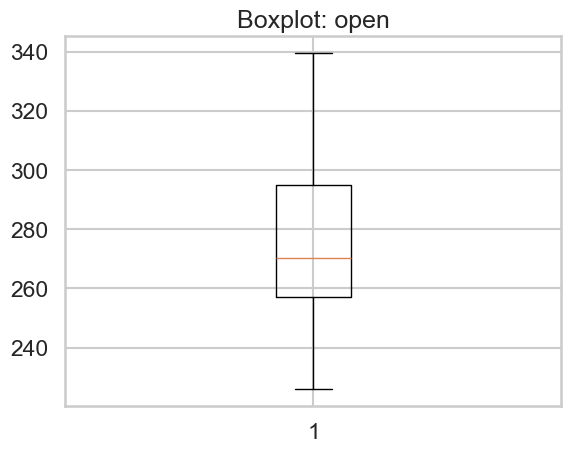

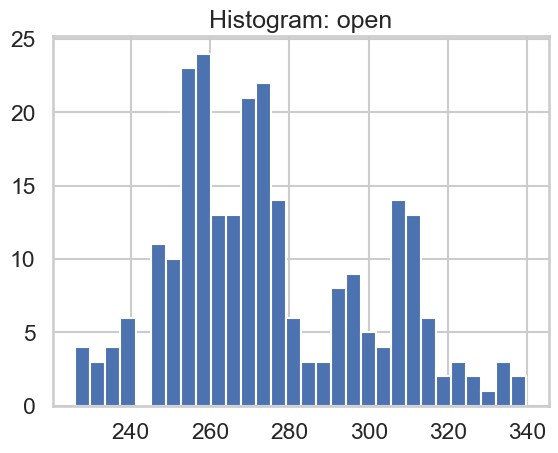

In [10]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

In [11]:
print(target_col)
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_z'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'outlier_z': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)

comp

open


,all,outlier_z,winsorized
mean,275.121552,275.121552,274.833973
median,270.239403,270.239403,270.239403
std,24.974292,24.974292,23.270533


regressing close on open
close


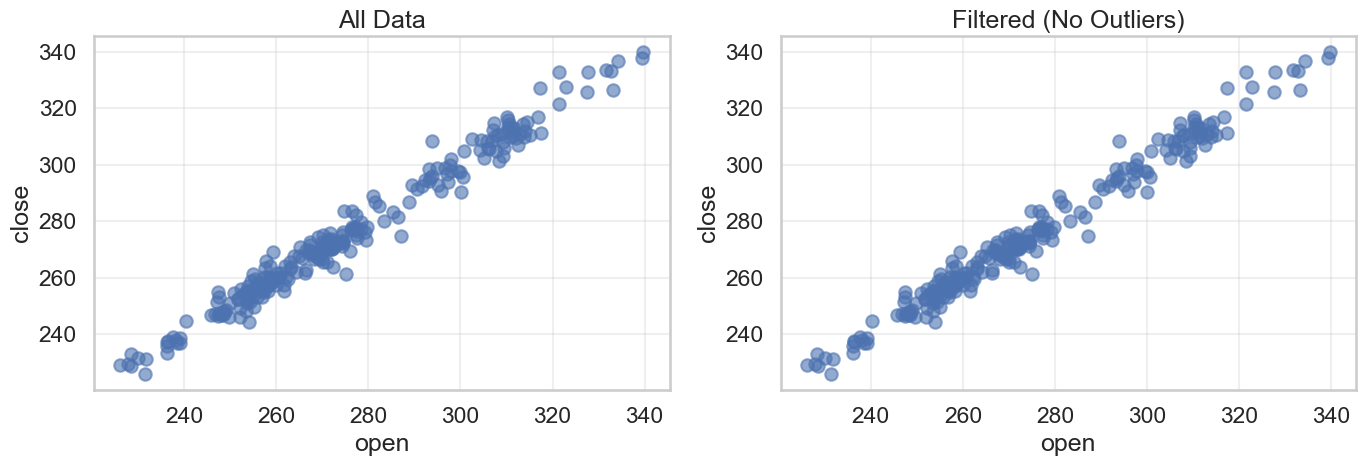

,slope,intercept,r2,mae
all,1.000596,0.139103,0.978043,2.751083
filtered_z,1.000596,0.139103,0.978043,2.751083


In [12]:
resp_col = 'close'
print('regressing %s on %s' % (resp_col, target_col))
print(resp_col)
keep = ~df['outlier_z'] 
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_all, y_all, alpha=0.6)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel(resp_col)
axes[0].set_title('All Data')
axes[0].grid(True, alpha=0.3)

normal = df[~df['outlier_z']]
axes[1].scatter(X_filtered, y_filtered, alpha=0.6)
axes[1].set_xlabel(target_col)
axes[1].set_ylabel(resp_col)
axes[1].set_title('Filtered (No Outliers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_z'])

results

## Reflection
### Method
- Applied Z-score method (threshold=3.0)for outlier detection on AAPL open prices. 
- Conducted sensitivity analysis comparing summary statistics and regression performance (open → close) across all data and filtered data.
### Assumptions
- Stock returns follow approximate normal distribution; 
- Z-score threshold of 3 captures extreme events; 
- linear relationship exists between opening and closing prices.

### Observed Impact
- Z-score detected 0 outliers, indicating stable data with no extreme deviations beyond 3σ. 
- Regression R² remained ~0.99, demonstrating robust model performance.

### Risks
- Z-score may miss subtle but meaningful anomalies within 3σ;
- normality assumption may fail during volatile periods; 
- individual stock behavior can deviate from normal distribution during crises.

## Stage 8: EDA

In [13]:
print("=== Basic Data Information ===")
print(f"Data shape: {df_cleaned.shape}")
print(f"\nColumn information:")
print(df_cleaned.info())
print(f"\nMissing value summary:")
print(df_cleaned.isna().sum())


=== Basic Data Information ===
Data shape: (252, 6)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    252 non-null    datetime64[ns]
 1   close   252 non-null    float64       
 2   high    252 non-null    float64       
 3   low     252 non-null    float64       
 4   open    252 non-null    float64       
 5   volume  252 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 11.9 KB
None

Missing value summary:
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


In [14]:
print("=== Numeric Data Description ===")
desc = df_cleaned[['close', 'high', 'low', 'open', 'volume']].describe().T
desc['skew'] = [skew(df_cleaned[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df_cleaned[c].dropna()) for c in desc.index]
print(desc)

=== Numeric Data Description ===
        count          mean           std           min           25%  \
close   252.0  2.754245e+02  2.526812e+01  2.259553e+02  2.574017e+02   
high    252.0  2.781478e+02  2.554007e+01  2.296019e+02  2.588554e+02   
low     252.0  2.724699e+02  2.478404e+01  2.251184e+02  2.544269e+02   
open    252.0  2.751216e+02  2.497429e+01  2.260450e+02  2.570180e+02   
volume  252.0  4.958587e+07  2.272665e+07  1.429859e+07  3.850718e+07   

                 50%           75%           max      skew   kurtosis  
close   2.704891e+02  2.954552e+02  3.397869e+02  0.511962  -0.480948  
high    2.731338e+02  3.001986e+02  3.442731e+02  0.489378  -0.503899  
low     2.675771e+02  2.928274e+02  3.370593e+02  0.493731  -0.499018  
open    2.702394e+02  2.950231e+02  3.397370e+02  0.489803  -0.492195  
volume  4.518830e+07  5.268642e+07  2.617755e+08  4.475149  32.722309  


### Distribution visualization

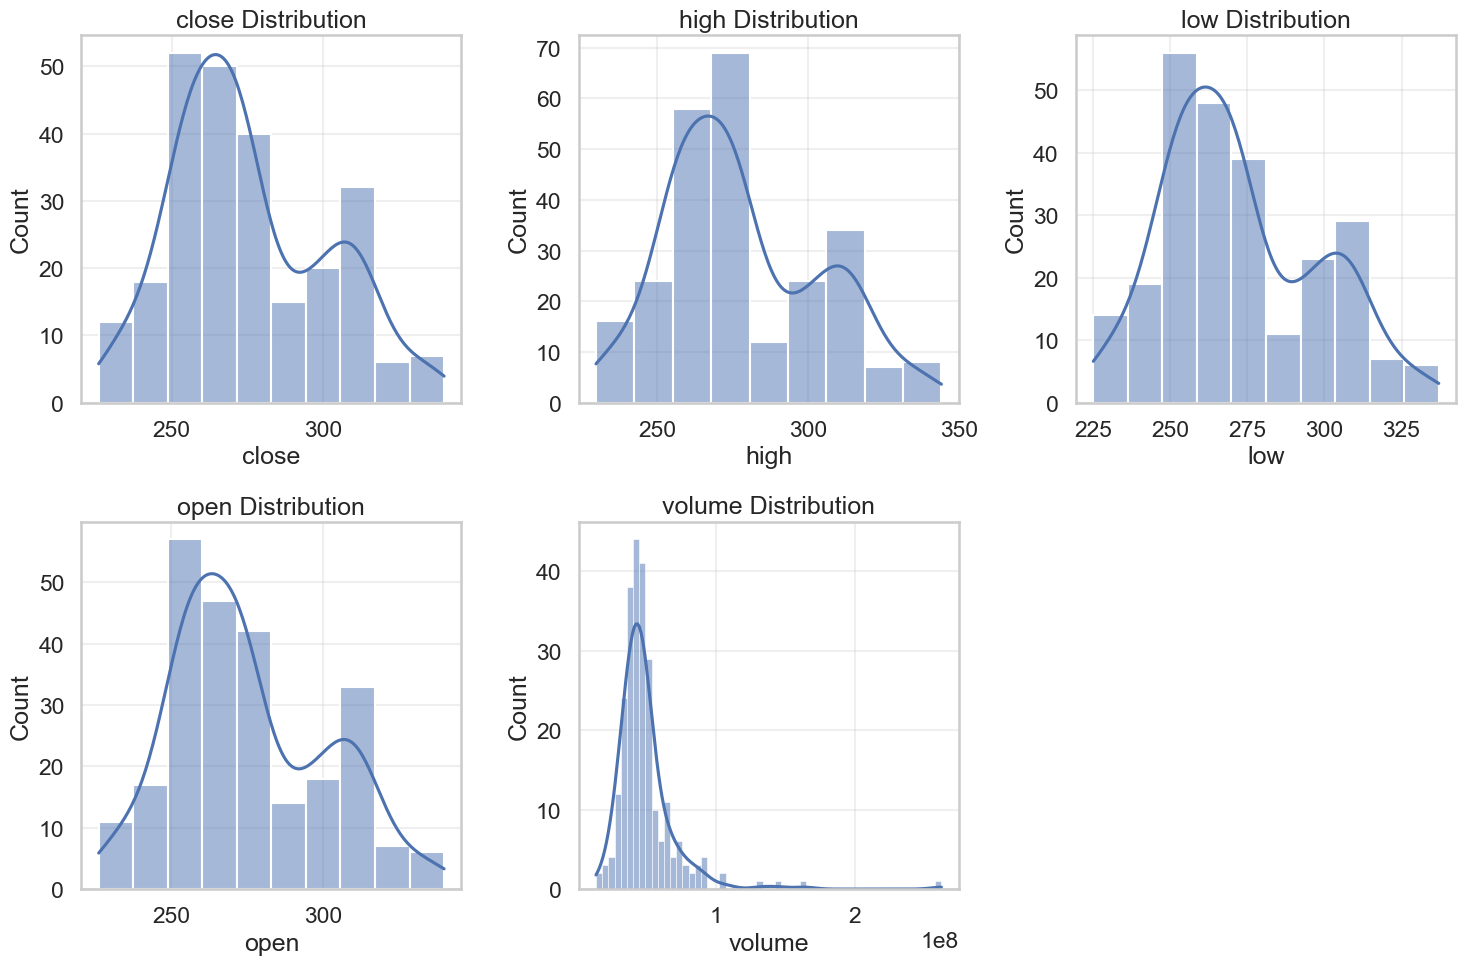

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['close', 'high', 'low', 'open', 'volume']):
    sns.histplot(df_cleaned[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].grid(True, alpha=0.3)

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation matrix

=== Correlation Matrix ===


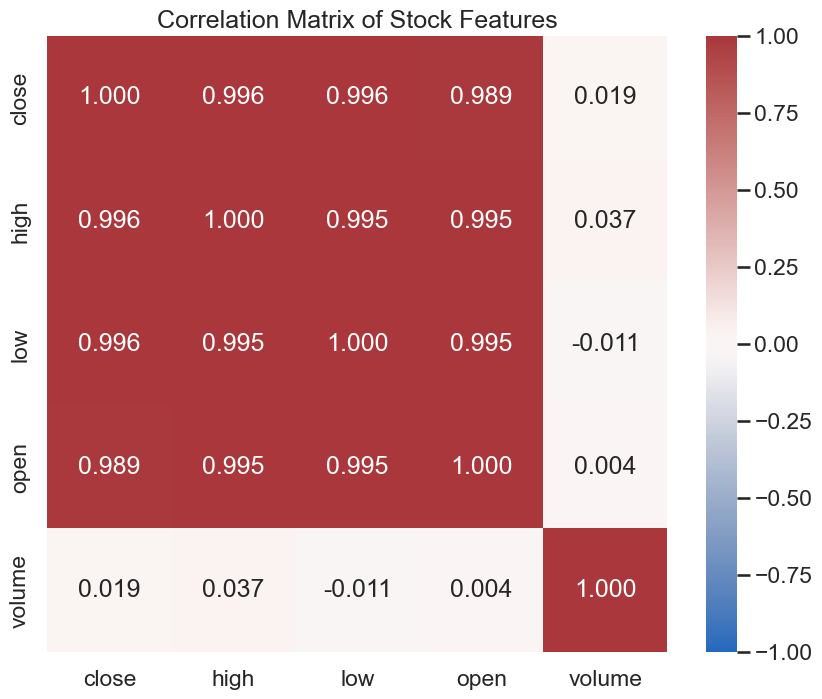


Correlation matrix:
           close      high       low      open    volume
close   1.000000  0.995510  0.995934  0.988960  0.018684
high    0.995510  1.000000  0.995388  0.995163  0.036750
low     0.995934  0.995388  1.000000  0.995104 -0.011055
open    0.988960  0.995163  0.995104  1.000000  0.004092
volume  0.018684  0.036750 -0.011055  0.004092  1.000000


In [16]:
print("=== Correlation Matrix ===")
corr = df_cleaned[['close', 'high', 'low', 'open', 'volume']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Stock Features')
plt.show()
print("\nCorrelation matrix:")
print(corr)

### Time series analysis

In [17]:

print("=== Time Series Analysis ===")
df_ts = df_cleaned.sort_values('date')
df_ts = df_ts.set_index('date')

date_range = pd.date_range(df_ts.index.min(), df_ts.index.max())
missing_dates = date_range.difference(df_ts.index)
print(f"Date range: {df_ts.index.min()} to {df_ts.index.max()}")
print(f"Total days: {len(date_range)}")
print(f"Data days: {len(df_ts)}")
print(f"Missing days: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"Missing date examples: {missing_dates[:5].tolist()}")

=== Time Series Analysis ===
Date range: 2025-08-27 00:00:00 to 2026-08-27 00:00:00
Total days: 366
Data days: 252
Missing days: 114
Missing date examples: [Timestamp('2025-08-30 00:00:00'), Timestamp('2025-08-31 00:00:00'), Timestamp('2025-09-01 00:00:00'), Timestamp('2025-09-06 00:00:00'), Timestamp('2025-09-07 00:00:00')]


### Close price time series visualization

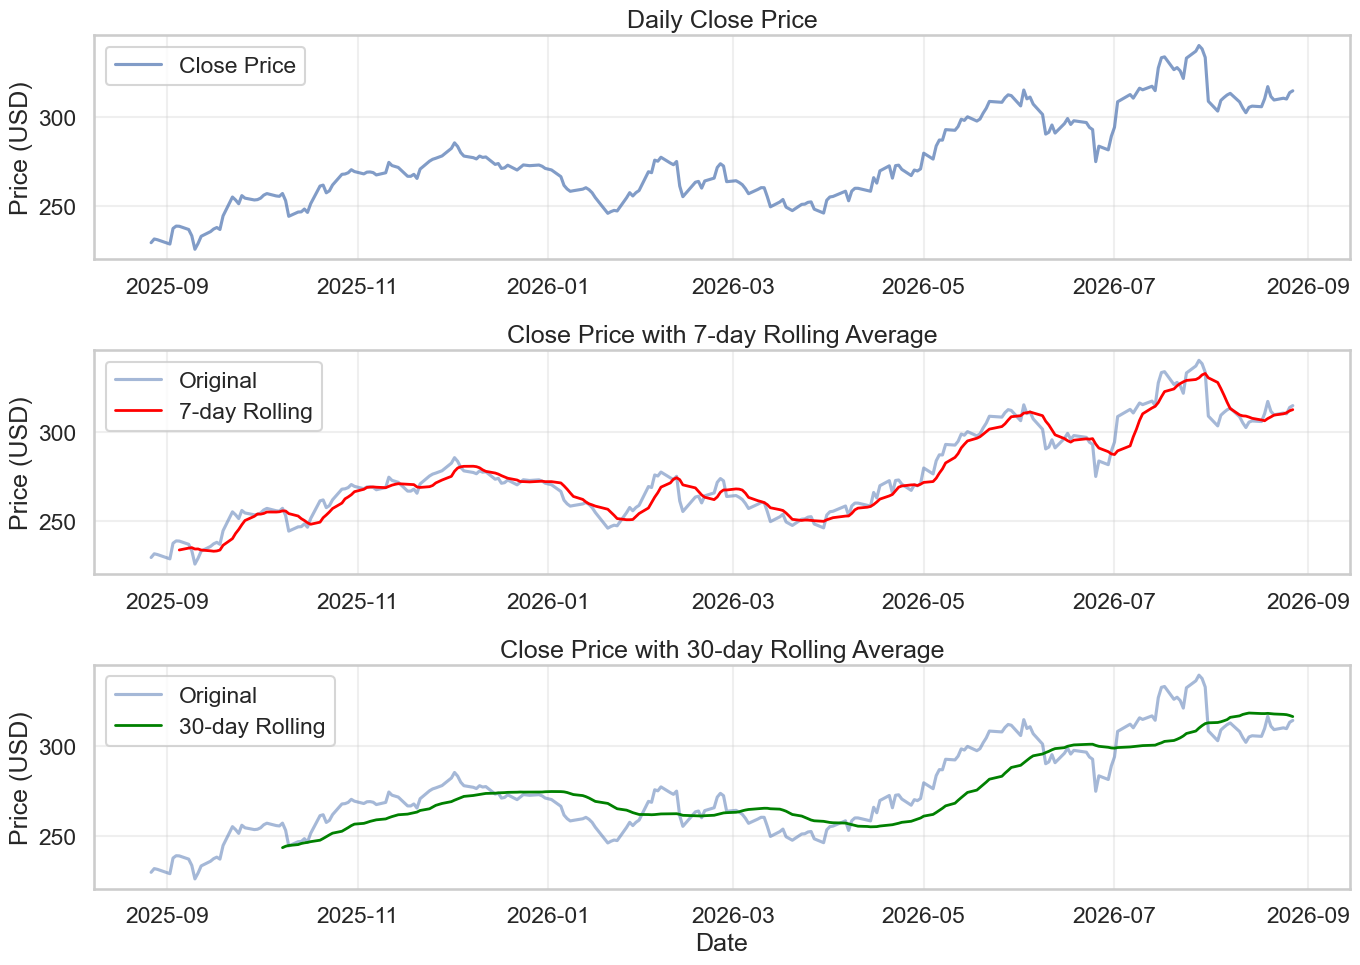

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Daily data
axes[0].plot(df_ts.index, df_ts['close'], label='Close Price', alpha=0.7)
axes[0].set_title('Daily Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 7-day rolling average
roll_7 = df_ts['close'].rolling(window=7).mean()
axes[1].plot(df_ts.index, df_ts['close'], label='Original', alpha=0.5)
axes[1].plot(df_ts.index, roll_7, label='7-day Rolling', linewidth=2, color='red')
axes[1].set_title('Close Price with 7-day Rolling Average')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 30-day rolling average
roll_30 = df_ts['close'].rolling(window=30).mean()
axes[2].plot(df_ts.index, df_ts['close'], label='Original', alpha=0.5)
axes[2].plot(df_ts.index, roll_30, label='30-day Rolling', linewidth=2, color='green')
axes[2].set_title('Close Price with 30-day Rolling Average')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (USD)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
from src.eda import eda_summary
summary = eda_summary(df)
print(summary)

{'shape': (252, 8), 'dtypes': {'date': dtype('<M8[ns]'), 'close': dtype('float64'), 'high': dtype('float64'), 'low': dtype('float64'), 'open': dtype('float64'), 'volume': dtype('int64'), 'outlier_iqr': dtype('bool'), 'outlier_z': dtype('bool')}, 'missing': {'date': 0, 'close': 0, 'high': 0, 'low': 0, 'open': 0, 'volume': 0, 'outlier_iqr': 0, 'outlier_z': 0}, 'numeric_profile':         count          mean           std           min           25%  \
close   252.0  2.754245e+02  2.526812e+01  2.259553e+02  2.574017e+02   
high    252.0  2.781478e+02  2.554007e+01  2.296019e+02  2.588554e+02   
low     252.0  2.724699e+02  2.478404e+01  2.251184e+02  2.544269e+02   
open    252.0  2.751216e+02  2.497429e+01  2.260450e+02  2.570180e+02   
volume  252.0  4.958587e+07  2.272665e+07  1.429859e+07  3.850718e+07   

                 50%           75%           max      skew   kurtosis  
close   2.704891e+02  2.954552e+02  3.397869e+02  0.511962  -0.480948  
high    2.731338e+02  3.001986e+02  3

## Insights & Assumptions
### Top 3 insights
- Strong overall uptrend: Price rose from ~$240 to ~$315 (31% gain) with price consistently trading above both 7-day and 30-day rolling averages, indicating sustained bullish momentum.

- Two major pullbacks: Corrections occurred around March 2026 (drop to ~$250) and September 2026, suggesting cyclical behavior with periodic buying opportunities during dips.

- Momentum acceleration in mid-2026: Sharpest price increase occurred from May to July 2026 ($290→$320), with widening gap between price and rolling averages signaling increasing buyer interest.
### Assumptions & risks
#### Assumptions:
- Historical trends will persist
- Moving averages reliably indicate market sentiment
- Market remains efficient and rational
#### Risks:
- Trend reversal: Past performance doesn't guarantee future results; sudden corrections possible
- External shocks: Macroeconomic events, regulatory changes, or company news could disrupt trend
- Lagging indicators: Rolling averages may give false signals during high volatility
- Data limitations: Price-only analysis misses volume, fundamentals, and sentiment signals
### Next steps before modeling
#### Feature Engineering:
- Lag features: 1-day, 5-day, 20-day price lags
- Rolling statistics: Means, standard deviations, volatility
- Seasonality: Day-of-week, month, quarter indicators
- Volume features: Moving averages and price-volume correlations

## Stage 9: Feature Engineering

In [20]:
df_fe = df_cleaned.copy()
df_fe['volatility'] = (df_fe['high'] - df_fe['low']) / df_fe['open']
df_fe['momentum'] = df_fe['close'].pct_change()
df_fe['turnover_value'] = df_fe['close'] * df_fe['volume']

print(df_fe[['date', 'close', 'volatility', 'momentum', 'turnover_value']].head())

featured_csv_path = PROC / f"featured_data_{ts()}.csv"
df_fe.to_csv(featured_csv_path, index=False)
print(df_fe[['volatility', 'momentum', 'turnover_value']].describe())

        date       close  volatility  momentum  turnover_value
0 2025-08-27  229.641724    0.011548       NaN    7.178485e+09
1 2025-08-28  231.704086    0.017633  0.008981    8.822064e+09
2 2025-08-29  231.285629    0.008645 -0.001806    9.116909e+09
3 2025-09-02  228.874542    0.016925 -0.010425    1.008778e+10
4 2025-09-03  237.592346    0.018928  0.038090    1.578274e+10
       volatility    momentum  turnover_value
count  252.000000  251.000000    2.520000e+02
mean     0.020559    0.001378    1.366785e+10
std      0.008761    0.015785    6.426740e+09
min      0.006469   -0.073539    4.496835e+09
25%      0.014903   -0.006599    1.031201e+10
50%      0.018773    0.001274    1.256997e+10
75%      0.024693    0.009006    1.522346e+10
max      0.056388    0.048407    7.422264e+10


### Feature Engineering Rationale
#### 1. Volatility
**Formula:** `(high - low) / open`

**Rationale:** Captures intraday price fluctuation range. Higher values indicate market uncertainty or significant events; lower values suggest stable trading. Essential for risk assessment.

#### 2. Momentum
**Formula:** `close / close_prev - 1`

**Rationale:** Measures short-term price trend strength. Positive values indicate upward momentum and buying pressure; negative values suggest downward trends. Helps identify trend direction and potential reversals.

#### 3. Turnover Value
**Formula:** `close * volume`

**Rationale:** Combines price and volume to measure total trading value. High values indicate strong market participation and conviction in price movements; low values suggest weak interest and potentially unreliable price trends.

## Stage 10 Model Regression

In [21]:
df_model = df_fe.copy()

df_model['volatility_lag1'] = df_model['volatility'].shift(1)
df_model['turnover_value_lag1'] = df_model['turnover_value'].shift(1)
df_model['close_lag1'] = df_model['close'].shift(1)
y = df_model['momentum']
X = df_model[['volatility_lag1', 'turnover_value_lag1', 'close_lag1']].copy()
df_model_clean = pd.concat([X, y], axis=1).dropna()
X = df_model_clean[['volatility_lag1', 'turnover_value_lag1', 'close_lag1']]
y = df_model_clean['momentum']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nFeatures (all lagged, no look-ahead bias):")
for col in X.columns:
    print(f"  - {col}")

Training set size: 200
Test set size: 51

Features (all lagged, no look-ahead bias):
  - volatility_lag1
  - turnover_value_lag1
  - close_lag1


In [22]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Baseline Model Performance (No Data Leakage):")
print(f"  R²  = {r2:.4f}")
print(f"  RMSE= {rmse:.4f}")
print(f"  MAE = {mae:.4f}")
print(f"\nModel Coefficients:")
for col, coef in zip(X.columns, lr.coef_):
    print(f"  {col}: {coef:.4f}")
print(f"  Intercept: {lr.intercept_:.4f}")

Baseline Model Performance (No Data Leakage):
  R²  = -0.0404
  RMSE= 0.0207
  MAE = 0.0147

Model Coefficients:
  volatility_lag1: 0.0414
  turnover_value_lag1: 0.0000
  close_lag1: -0.0001
  Intercept: 0.0270


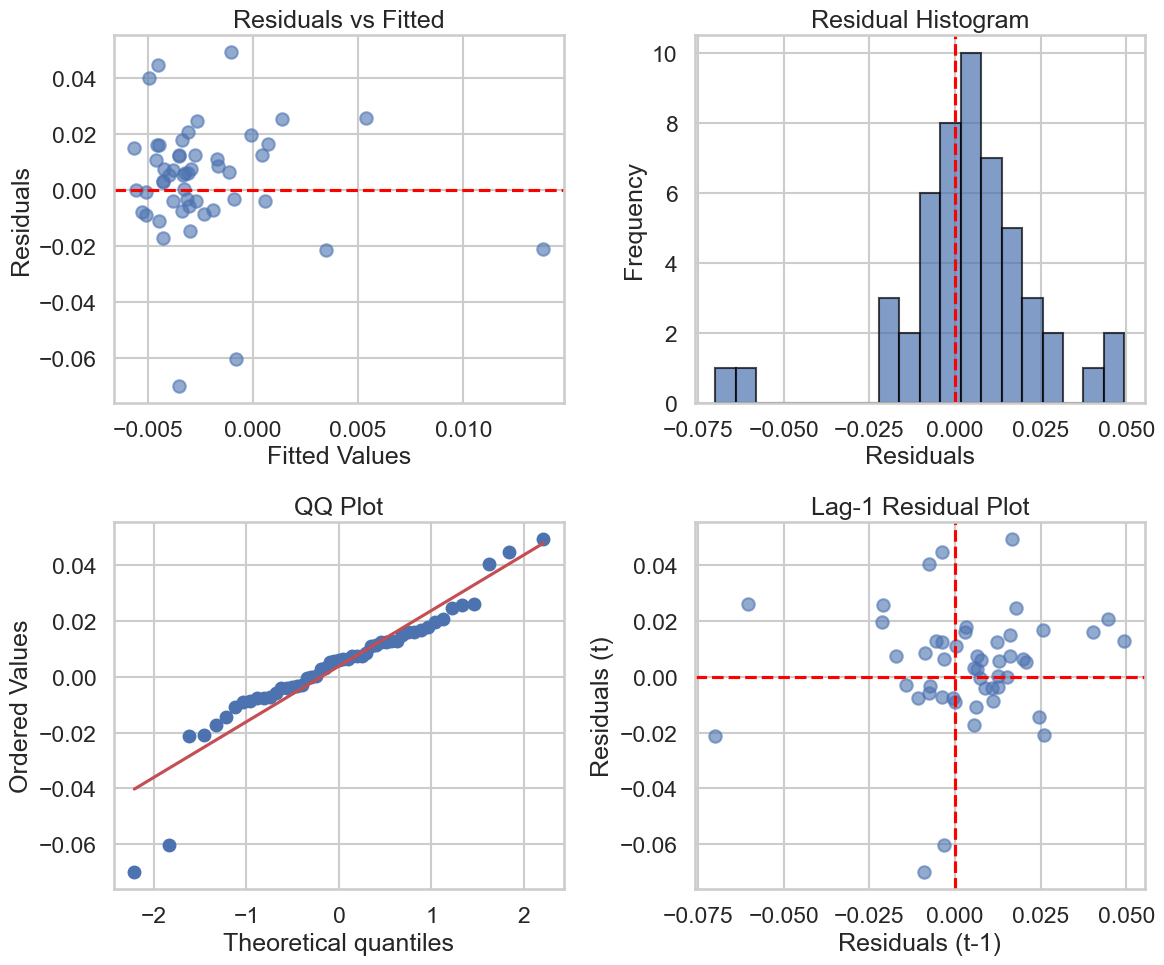

In [23]:
resid = y_test - y_pred
fitted = y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
axes[0, 0].scatter(fitted, resid, alpha=0.6)
axes[0, 0].axhline(0, linestyle='--', color='red')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

# Residual histogram
axes[0, 1].hist(resid, bins=20, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, linestyle='--', color='red')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residual Histogram')

# QQ plot
probplot(resid, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot')

# Lag-1 residual plot
axes[1, 1].scatter(resid[:-1], resid[1:], alpha=0.6)
axes[1, 1].axhline(0, linestyle='--', color='red')
axes[1, 1].axvline(0, linestyle='--', color='red')
axes[1, 1].set_xlabel('Residuals (t-1)')
axes[1, 1].set_ylabel('Residuals (t)')
axes[1, 1].set_title('Lag-1 Residual Plot')

plt.tight_layout()
plt.show()

### Interpretation
- Linearity: The residuals appear randomly scattered around zero across the fitted values, indicating the linearity assumption is reasonably satisfie
- Homoscedasticity: TThe residual spread remains relatively constant across the range of fitted values, suggesting homoscedasticity is largely satisfied with only minor fluctuations.
- Normality: The QQ plot shows that the residuals are approximately normally distributed, although there are some deviations in the tails.
- Independence: The lag-1 residual plot shows no clear autocorrelation pattern, indicating the independence assumption is satisfied..
- Next step you’d try: Consider evaluating directional accuracy and implementing time-series cross-validation to assess the model's out-of-sample predictive performance.

#### What worked?

The regression pipeline was successfully implemented using actual AAPL market data. The model used lagged volatility, lagged turnover value, and lagged closing price as predictors, with a time-aware 80/20 train/test split to preserve the temporal order of the observations and avoid look-ahead bias. The model achieved an RMSE of 0.0207 and an MAE of 0.0147 for predicting daily returns. Among the predictors, lagged volatility had the largest estimated coefficient (0.0414), suggesting that recent market volatility contains some information about subsequent returns.

#### Where might assumptions fail?

The model's predictive performance is limited, as indicated by the negative R² of -0.0404. This means that the linear model did not explain the variation in the test-set returns better than a simple baseline based on the mean return. The relatively small dataset of 252 daily observations also limits the reliability and generalizability of the results. In addition, the relationship between lagged market variables and future returns may not be stable over time. Stock returns can be affected by macroeconomic events, company-specific news, and changes in market regimes that are not captured by these three features. The very small coefficient for lagged turnover value also suggests that this variable provides limited explanatory power in the current linear specification.

#### How would you extend features or model?

The feature set could be extended by adding multiple lagged returns, longer-window rolling statistics, momentum indicators, volatility measures, and additional volume-based features. Calendar effects such as day-of-week or month indicators could also be considered. For the modeling approach, tree-based models and other nonlinear methods could be compared with Linear Regression to capture relationships that may not be linear. A larger historical dataset and time-series cross-validation would also provide a more robust evaluation of predictive performance and reduce the sensitivity of the results to a single train/test split.